In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
%matplotlib inline
import tensorflow as tf
import keras
import glob
import cv2
import pickle, datetime

from keras.models import Model, Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D, ZeroPadding2D
from keras.layers import LSTM, Input, TimeDistributed, Convolution2D, Activation
from keras.optimizers import RMSprop, SGD
from keras.layers import BatchNormalization
from keras.utils import to_categorical
from keras import optimizers
from keras.preprocessing import sequence
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.models import load_model

from sklearn.preprocessing import LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os
import glob
print(os.listdir("../MRI_DATASET/"))



['Testing', 'Training']


In [2]:
import glob
import os
import cv2
import numpy as np

# Load training images and labels
train_images = []
train_labels = []
image_size = 128  # Replace with the desired image size

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Training', '*')):
    label = os.path.basename(directory_path)
    print("Training label found:", label)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            train_images.append(img)
            train_labels.append(label)

train_images = np.array(train_images, dtype=np.float32)
train_labels = np.array(train_labels)

print(f'Loaded {len(train_images)} training images with labels {train_labels}')
label_to_id = {v: i for i, v in enumerate(np.unique(train_labels))}
id_to_label = {v: k for k, v in label_to_id.items()}
train_label_ids = np.array([label_to_id[x] for x in train_labels])

print("Label to ID mapping:", label_to_id)
print("ID to Label mapping:", id_to_label)

# Load testing images and labels
test_images = []
test_labels = []

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Testing', '*')):
    label = os.path.basename(directory_path)
    print("Testing label found:", label)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            test_images.append(img)
            test_labels.append(label)

test_images = np.array(test_images, dtype=np.float32)
test_labels = np.array(test_labels)

print(f'Loaded {len(test_images)} testing images with labels {test_labels}')
test_label_ids = np.array([label_to_id[x] for x in test_labels])


Training label found: glioma
Training label found: meningioma
Training label found: notumor
Training label found: pituitary
Loaded 6984 training images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']
Label to ID mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
ID to Label mapping: {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}
Testing label found: glioma
Testing label found: meningioma
Testing label found: notumor
Testing label found: pituitary
Loaded 2063 testing images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [2]:
train_images = []
train_labels = []
image_size = 128  # Replace with the desired image size

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Training', '*')):
    label = os.path.basename(directory_path)
    print(label)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            train_images.append(img)
            train_labels.append(label)

train_images = np.array(train_images, dtype=np.float32)
train_labels = np.array(train_labels)

print(f'Loaded {len(train_images)} images with labels {train_labels}')
label_to_id = {v:i for i,v in enumerate(np.unique(train_labels))}
id_to_label = {v: k for k, v in label_to_id.items()}
train_label_ids = np.array([label_to_id[x] for x in train_labels])


glioma
meningioma
notumor
pituitary
Loaded 6984 images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [3]:
test_images = []
test_labels = []
image_size = 128  # Replace with the desired image size

for directory_path in glob.glob(os.path.join('../MRI_DATASET', 'Testing', '*')):
    label = os.path.basename(directory_path)
    for img_path in glob.glob(os.path.join(directory_path, '*')):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            test_images.append(img)
            test_labels.append(label)

test_images = np.array(test_images, dtype=np.float32)
test_labels = np.array(test_labels)

print(f'Loaded {len(test_images)} images with labels {test_labels}')
test_label_ids = np.array([label_to_id[x] for x in test_labels])


Loaded 2063 images with labels ['glioma' 'glioma' 'glioma' ... 'pituitary' 'pituitary' 'pituitary']


In [4]:
from keras.applications.xception import Xception

In [19]:
xcp = Xception(input_shape = (128,128,3), weights='imagenet', include_top = False)

In [20]:
for i in xcp.layers:
    i.trainable = False

In [21]:
n_classes = 4

In [22]:
x = Flatten()(xcp.output)
#x = Dense(512, activation='relu')(x)
#x = layers.Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(n_classes, activation='softmax')(x)

In [23]:
from keras.models import Model

In [24]:
# Create the final model
xcp_model = Model(inputs=xcp.input, outputs=output)

In [25]:
# Compile the model
xcp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
X_normalized = np.array(train_images / 255.0 - 0.5 )
X_normalized_test = np.array(test_images / 255.0 - 0.5 )

label_binarizer = LabelBinarizer()
y_one_hot = label_binarizer.fit_transform(train_label_ids)
y_one_hot_test = label_binarizer.fit_transform(test_label_ids)

In [27]:
xcp_model.fit(X_normalized, y_one_hot, batch_size=5, epochs=10,verbose=1, validation_data=(X_normalized_test,y_one_hot_test))

Epoch 1/10


1397/1397 [==============================] - 605s 354ms/step - loss: 1.2047 - accuracy: 0.6826 - val_loss: 0.6444 - val_accuracy: 0.7722
Epoch 2/10
1397/1397 [==============================] - 454s 325ms/step - loss: 0.6670 - accuracy: 0.7447 - val_loss: 0.4570 - val_accuracy: 0.8284
Epoch 3/10
1397/1397 [==============================] - 445s 318ms/step - loss: 0.5994 - accuracy: 0.7708 - val_loss: 0.4553 - val_accuracy: 0.8260
Epoch 4/10
1397/1397 [==============================] - 448s 321ms/step - loss: 0.5423 - accuracy: 0.7954 - val_loss: 0.4106 - val_accuracy: 0.8512
Epoch 5/10
1397/1397 [==============================] - 445s 319ms/step - loss: 0.4828 - accuracy: 0.8094 - val_loss: 0.3683 - val_accuracy: 0.8623
Epoch 6/10
1397/1397 [==============================] - 443s 317ms/step - loss: 0.4803 - accuracy: 0.8127 - val_loss: 0.4010 - val_accuracy: 0.8541
Epoch 7/10
1397/1397 [==============================] - 443s 317ms/step - loss: 0.4286 - accuracy: 0.8349 - va

In [28]:
xcp_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 63, 63, 32)           864       ['input_2[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 63, 63, 32)           128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 63, 63, 32)           0         ['block1_conv1_bn[0][0]'

In [29]:
xcp_model.save('xcp_ensemble.h5')

C:\Users\aduser\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
layer_name = 'dense_3'
FC_layer_model = Model(inputs=xcp_model.input, outputs=xcp_model.get_layer(layer_name).output)

features = np.zeros(shape=(train_images.shape[0], 256))
i = 0
for directory_path in glob.glob("../MRI_DATASET/Training/*"):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)    
            img = cv2.resize(img, (128, 128))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img = np.expand_dims(img, axis=0)
            FC_output = FC_layer_model.predict(img)
            features[i] = FC_output
            i += 1

np.save('features', features)

1/1 [==============================] - 0s 110ms/step


In [31]:
train_features = pd.DataFrame(data=features)
train_label_ids = np.array([label_to_id[x] for x in train_labels])

In [32]:
features_test = np.zeros(shape=(test_images.shape[0], 256))
i = 0
for directory_path in glob.glob("../MRI_DATASET/Testing/*"):
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)    
            img = cv2.resize(img, (128, 128))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            img = np.expand_dims(img, axis=0)
            FC_output = FC_layer_model.predict(img)
            features_test[i] = FC_output
            i += 1

test_features = pd.DataFrame(data=features_test)
test_label_ids = np.array([label_to_id[x] for x in test_labels])

1/1 [==============================] - 0s 92ms/step


In [33]:
np.save('test_features', test_features)

In [34]:
rf = RandomForestClassifier(n_estimators=20, random_state=42, max_features=4)
rf.fit(train_features, train_label_ids)

RandomForestClassifier(max_features=4, n_estimators=20, random_state=42)

In [35]:
predictions_rf = rf.predict(test_features)
accuracy = accuracy_score(predictions_rf, test_label_ids)
print('Accuracy:', accuracy * 100, '%.')

Accuracy: 73.67910809500728 %.


In [36]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

In [37]:
# Generate the confusion matrix for Random Forest
conf_matrix_rf = confusion_matrix(predictions_rf, test_label_ids)
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Confusion Matrix:
[[259  76  17  50]
 [124 368  18  36]
 [ 19  22 496  21]
 [102  44  14 397]]


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
# Generate the classification report for Random Forest
class_report_rf = classification_report(test_label_ids, predictions_rf)
print("\nRandom Forest Classification Report:")
print(class_report_rf)


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.51      0.57       504
           1       0.67      0.72      0.70       510
           2       0.89      0.91      0.90       545
           3       0.71      0.79      0.75       504

    accuracy                           0.74      2063
   macro avg       0.73      0.73      0.73      2063
weighted avg       0.73      0.74      0.73      2063



In [40]:
import numpy as np 
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
dt = DecisionTreeClassifier()
dt.fit (train_features, train_label_ids)

DecisionTreeClassifier()

In [42]:
predictions_dt = dt.predict(test_features)
accuracy_dt = accuracy_score(predictions_dt, test_label_ids)
print('Accuracy:', accuracy_dt * 100, '%.')

Accuracy: 68.20164808531266 %.


In [43]:
# Generate the confusion matrix for Random Forest
conf_matrix_dt = confusion_matrix(predictions_dt, test_label_ids)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_dt)

Decision Tree Confusion Matrix:
[[211  69  21  55]
 [127 375  43  61]
 [ 50  19 457  24]
 [116  47  24 364]]


In [44]:
svm = SVC()
svm.fit (train_features, train_label_ids)

SVC()

In [45]:
predictions_svm = svm.predict(test_features)
accuracy_svm = accuracy_score(predictions_svm, test_label_ids)
print('Accuracy:', accuracy_svm * 100, '%.')

Accuracy: 56.71352399418323 %.


In [46]:
# Generate the confusion matrix for Random Forest
conf_matrix_svm = confusion_matrix(predictions_svm, test_label_ids)
print("Decision Tree Confusion Matrix:")
print(conf_matrix_svm)

Decision Tree Confusion Matrix:
[[269 142  59  65]
 [ 70 155  34  41]
 [ 16  99 388  40]
 [149 114  64 358]]


In [47]:
# Load the features
features = np.load('features.npy')
test_features = np.load('test_features.npy')

In [48]:
# Create DataFrames
train_features = pd.DataFrame(data=features)
test_features = pd.DataFrame(data=test_features)

In [49]:
# Define the classifiers
rf = RandomForestClassifier(n_estimators=20, random_state=42, max_features=4)
dt = DecisionTreeClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)

In [50]:
# Train the classifiers
rf.fit(train_features, train_label_ids)
dt.fit(train_features, train_label_ids)
svm.fit(train_features, train_label_ids)

SVC(probability=True, random_state=42)

In [51]:
# Combine classifiers into a VotingClassifier
ensemble_model = VotingClassifier(estimators=[
    ('rf', rf), 
    ('dt', dt), 
    ('svm', svm)
], voting='soft')

In [52]:
# Train the VotingClassifier
ensemble_model.fit(train_features, train_label_ids)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_features=4,
                                                     n_estimators=20,
                                                     random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('svm', SVC(probability=True, random_state=42))],
                 voting='soft')

In [53]:
# Predict on the test data
predictions_ensemble = ensemble_model.predict(test_features)

In [54]:
# Evaluate the ensemble model
accuracy = accuracy_score(test_label_ids, predictions_ensemble)
print('Ensemble Model Accuracy:', accuracy*100, '%')

Ensemble Model Accuracy: 70.28599127484246 %


In [55]:
# Generate the confusion matrix
conf_matrix_ensemble = confusion_matrix(test_label_ids, predictions_ensemble)
print("Ensemble Model Confusion Matrix:")
print(conf_matrix_ensemble)

Ensemble Model Confusion Matrix:
[[226 127  42 109]
 [ 69 368  25  48]
 [ 16  19 492  18]
 [ 58  56  26 364]]


In [56]:
# Generate the classification report
class_report = classification_report(test_label_ids, predictions_ensemble)
print("\nEnsemble Model Classification Report:")
print(class_report)


Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.45      0.52       504
           1       0.65      0.72      0.68       510
           2       0.84      0.90      0.87       545
           3       0.68      0.72      0.70       504

    accuracy                           0.70      2063
   macro avg       0.69      0.70      0.69      2063
weighted avg       0.70      0.70      0.70      2063



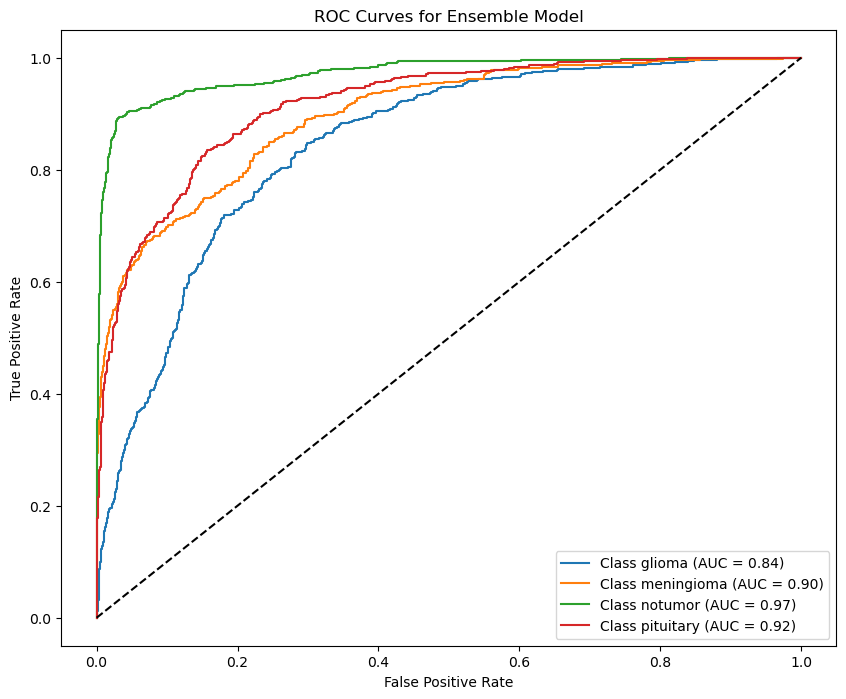

In [57]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC curves
y_test_binarized = label_binarize(test_label_ids, classes=[0, 1, 2, 3])

# Get prediction probabilities for ROC curve
y_pred_prob = ensemble_model.predict_proba(test_features)

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {id_to_label[i]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Ensemble Model')
plt.legend(loc='lower right')
plt.show()


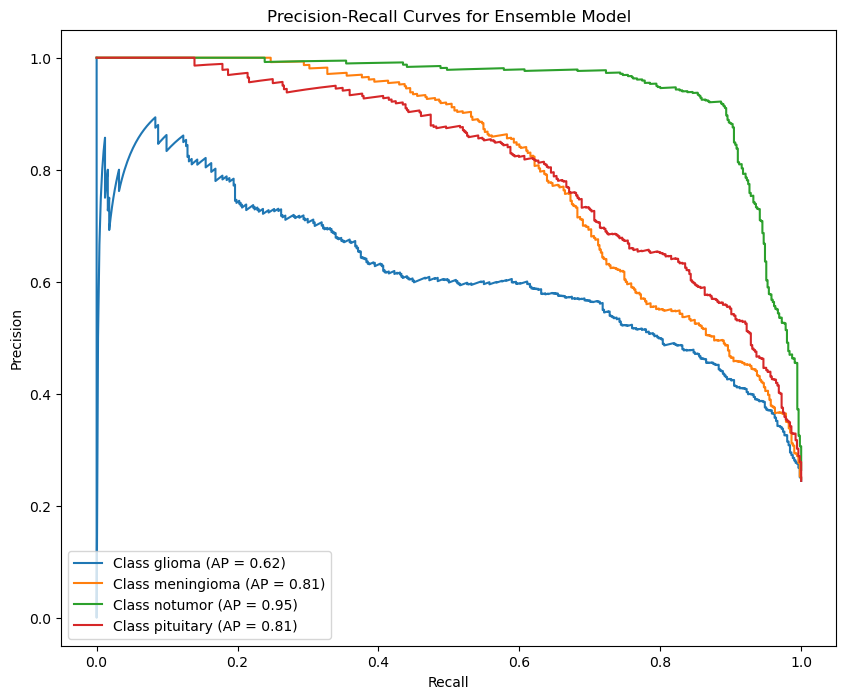

In [58]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot Precision-Recall curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    avg_precision = average_precision_score(y_test_binarized[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f'Class {id_to_label[i]} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Ensemble Model')
plt.legend(loc='lower left')
plt.show()


In [59]:
import joblib

In [60]:
joblib.dump(ensemble_model, 'xcp_ensemble_model.pkl')

['xcp_ensemble_model.pkl']